# Online Retail II — Notebook 1: Data Quality & Preparation

*A UK-based online gift retailer's transaction log (Kaggle: [Online Retail II](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci)), about 1.07M line items, Dec 2009 – Dec 2011.*

**This is notebook 1 of 2.** Its job is to *understand* the raw data, *assess its quality*, *fix it* (filter / impute / flag), and hand a clean, analysis-ready dataset to [Notebook 2](02_analysis_and_insights.ipynb) — while documenting the caveats, assumptions, and what would make this data more trustworthy.

> **Why split it this way?** In a real project, data preparation and analysis are different jobs with different audiences. Keeping them separate makes the cleaning decisions auditable and lets the analysis start from a trusted, reproducible base.

**Workflow**

1. Understand the grain and schema
2. Quantify every data-quality issue
3. Decide a treatment for each (with reasons)
4. Save a prepared dataset
5. Record caveats and recommendations

## About the data & business context

From the dataset's own documentation (and cross-checked against the data):

- A **UK-based, registered, non-store online retailer** selling mostly **all-occasion giftware**.
- **Many of its customers are wholesalers** — key context for how we later read "a customer", order sizes and pricing.
- Prices are in **pounds sterling (GBP)** — there is no currency column, so this is an assumption we carry forward.
- **Invoice numbers beginning with `C` are cancellations**; we also find an **`A` prefix** used for accounting **adjustments** (e.g. bad-debt write-offs).

We treat these as *given context* and verify each against the data as we go.

## 1. Setup & load

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# A clean, restrained plotting theme, reused across both notebooks.
NAVY, TEAL, LBLUE, CORAL, GRAY = "#14213D", "#0FA3B1", "#7DCFDD", "#E07A5F", "#9AA5B1"
plt.rcParams.update({
    "figure.figsize": (9, 4.4), "figure.dpi": 110, "font.size": 11,
    "axes.titleweight": "bold", "axes.titlecolor": NAVY, "axes.labelcolor": NAVY,
    "axes.edgecolor": GRAY, "axes.grid": True, "grid.color": "#ECEFF2",
    "text.color": NAVY, "xtick.color": NAVY, "ytick.color": NAVY,
    "axes.spines.top": False, "axes.spines.right": False,
})
money = lambda x, _=None: (f"£{x/1e6:.1f}M" if abs(x) >= 1e6 else f"£{x/1e3:.0f}k")  # £ axis formatter
DATA_DIR = Path("..") / "data"

In [2]:
# Load the raw CSV (downloads from Kaggle on first run; needs ~/.kaggle/kaggle.json).
# ISO-8859-1 encoding because some product descriptions contain non-UTF-8 bytes.
RAW = DATA_DIR / "online_retail_II.csv"
if not RAW.exists():
    import subprocess, sys
    DATA_DIR.mkdir(exist_ok=True)
    subprocess.run([sys.executable, "-m", "kaggle", "datasets", "download",
                    "-d", "mashlyn/online-retail-ii-uci", "-p", str(DATA_DIR), "--unzip"], check=True)

raw = pd.read_csv(RAW, encoding="ISO-8859-1")
raw.columns = [c.strip() for c in raw.columns]                      # tidy stray header whitespace
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"], errors="coerce")
raw["Revenue"] = raw["Quantity"] * raw["Price"]                     # no revenue column in source — derive it
print(f"{len(raw):,} rows x {raw.shape[1]} columns | "
      f"{raw['InvoiceDate'].min():%Y-%m-%d}  to  {raw['InvoiceDate'].max():%Y-%m-%d}")
raw.head()

1,067,371 rows x 9 columns | 2009-12-01  to  2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 2. What is one row? (grain & schema)

In [3]:
# dtypes, distinct values, and missingness for every column at a glance.
overview = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "n_unique": raw.nunique(),
    "pct_missing": (raw.isna().mean() * 100).round(2),
})
print(overview.to_string(), "\n")

# Key cardinalities — how many invoices / products / customers / countries.
print(f"invoices={raw['Invoice'].nunique():,}  products={raw['StockCode'].nunique():,}  "
      f"customers={raw['Customer ID'].nunique():,}  countries={raw['Country'].nunique()}")

# Is (Invoice, StockCode) a unique key? If not, the row itself is the grain.
print(f"\nrows sharing an (Invoice, StockCode) pair: "
      f"{raw.duplicated(subset=['Invoice','StockCode']).sum():,}  ->  NOT unique")

                      dtype  n_unique  pct_missing
Invoice              object     53628         0.00
StockCode            object      5305         0.00
Description          object      5698         0.41
Quantity              int64      1057         0.00
InvoiceDate  datetime64[ns]     47635         0.00
Price               float64      2807         0.00
Customer ID         float64      5942        22.77
Country              object        43         0.00
Revenue             float64      9113         0.00 



invoices=53,628  products=5,305  customers=5,942  countries=43

rows sharing an (Invoice, StockCode) pair: 45,947  ->  NOT unique


In [4]:
# Concrete example of the above: the SAME item recorded on several lines of one invoice.
raw[(raw["Invoice"].astype(str) == "577473") & (raw["StockCode"].astype(str) == "22097")] \
   [["Invoice", "StockCode", "Description", "Quantity", "Price", "InvoiceDate"]]

,Invoice,StockCode,Description,Quantity,Price,InvoiceDate
1007832,577473,22097,SWALLOW SQUARE TISSUE BOX,1,0.39,2011-11-20 11:28:00
1007841,577473,22097,SWALLOW SQUARE TISSUE BOX,2,0.39,2011-11-20 11:28:00
1007849,577473,22097,SWALLOW SQUARE TISSUE BOX,2,0.39,2011-11-20 11:28:00


**Grain = one invoice line item.** The example shows the same product (`22097`) recorded on three lines of the same invoice, at the same price and timestamp — so `(Invoice, StockCode)` is **not** a unique key, and the *row itself* is the grain. Two of those lines are *identical* (both quantity 2): with no line-level ID and only minute-resolution timestamps, a genuine repeated scan is indistinguishable from an accidental double-write — a point we return to under duplicates.

**Documented vs. actual schema** — worth checking before trusting the documentation:

- Invoices carry letter prefixes (`C` = cancellation, `A` = adjustment), not just digits.
- Stock codes include service codes and letter suffixes, not just 5-digit product numbers.
- There is **no revenue column** (we derive `Quantity × Price`) and **no currency field** (documented as GBP).

## 3. Data-quality assessment

Every issue is quantified *before* any fix, because each one changes the business numbers if ignored.

In [5]:
# Handy reusable series: string forms + the two invoice-prefix flags.
inv = raw["Invoice"].astype(str); sc = raw["StockCode"].astype(str)
is_cancel = inv.str.startswith("C")   # 'C' invoice = cancellation / credit note
is_adjust = inv.str.startswith("A")   # 'A' invoice = accounting adjustment (bad debt)

# Count each quality issue and express it as a % of all rows.
qc = {
    "exact duplicate rows":     raw.duplicated().sum(),
    "missing Customer ID":      raw["Customer ID"].isna().sum(),
    "missing Description":       raw["Description"].isna().sum(),
    "cancellation lines (C)":   is_cancel.sum(),
    "adjustment lines (A)":     is_adjust.sum(),
    "negative quantity":        (raw["Quantity"] < 0).sum(),
    "zero price":               (raw["Price"] == 0).sum(),
    "negative price":           (raw["Price"] < 0).sum(),
}
qc = pd.DataFrame({"count": qc}); qc["pct_of_rows"] = (qc["count"] / len(raw) * 100).round(2)
print(qc.to_string())

# Cancellations look tiny per-line but are large per-invoice — show both.
canc_inv = raw.loc[is_cancel, "Invoice"].nunique(); all_inv = raw["Invoice"].nunique()
print(f"\nCancelled invoices: {canc_inv:,} of {all_inv:,} = {canc_inv/all_inv*100:.1f}% of invoices "
      f"(only {is_cancel.mean()*100:.1f}% of lines, but 1-in-6 orders).")

                         count  pct_of_rows
exact duplicate rows     34335         3.22
missing Customer ID     243007        22.77
missing Description       4382         0.41
cancellation lines (C)   19494         1.83
adjustment lines (A)         6         0.00
negative quantity        22950         2.15
zero price                6202         0.58
negative price               5         0.00

Cancelled invoices: 8,292 of 53,628 = 15.5% of invoices (only 1.8% of lines, but 1-in-6 orders).


In [6]:
# Are the zero-price rows free samples, or administrative noise? Check before assuming.
z = raw[raw["Price"] == 0]
print(f"zero-price rows: {len(z):,}  |  {z['Customer ID'].isna().mean()*100:.0f}% have NO Customer ID")
print(z["Description"].fillna("<blank>").value_counts().head(8).to_string())   # top descriptions
print("\n-> mostly manual / damage / adjustment notes ('check', 'damages', 'found') — NOT sales.")

zero-price rows: 6,202  |  99% have NO Customer ID
Description
<blank>                  4382
check                     162
?                          92
damages                    84
damaged                    81
found                      28
missing                    27
sold as set on dotcom      20

-> mostly manual / damage / adjustment notes ('check', 'damages', 'found') — NOT sales.


### Which stock codes are *not* products?

Before we can classify lines, we need to know which stock codes are **services or adjustments**
rather than merchandise. Ordinary product codes look like 5–6 digits with an optional short
letter suffix for a colour/size variant (e.g. `85123A`, `15056BL`). Everything else is worth a
look:

In [7]:
# Flag codes that DON'T look like an ordinary product code, and list them with a sample
# description, how many rows they cover, and their revenue — so we can see what they are.
is_product_code = sc.str.match(r"^\d{5,6}[A-Za-z]{0,2}$")
odd = (raw.loc[~is_product_code]
          .assign(desc=raw["Description"].fillna("<blank>"))
          .groupby("StockCode")
          .agg(rows=("Invoice", "size"),
               revenue=("Revenue", "sum"),
               example_description=("desc", lambda s: s.mode().iat[0]))
          .sort_values("rows", ascending=False))
print(odd.head(20).to_string())

              rows     revenue                  example_description
StockCode                                                          
POST          2122  112341.000                              POSTAGE
DOT           1446  322647.470                       DOTCOM POSTAGE
M             1421  -82796.320                               Manual
C2             282   13386.000                             CARRIAGE
D              177  -13484.540                             Discount
S              104   -6065.800                              SAMPLES
BANK CHARGES   102  -35562.629                         Bank Charges
ADJUST          67    6835.240  Adjustment by john on 26/01/2010 16
AMAZONFEE       43 -260763.580                           AMAZON FEE
DCGS0058        31      34.820                     MISO PRETTY  GUM
gift_0001_20    29     471.060  Dotcomgiftshop Gift Voucher Â£20.00
gift_0001_30    29     610.090  Dotcomgiftshop Gift Voucher Â£30.00
DCGSSGIRL       25     295.630                  

The list above is a **mix of two things**:

- **Genuine services / adjustments** — postage (`POST`, `DOT`, `C2`), manual corrections (`M`),
  discounts (`D`), samples (`S`), fees (`AMAZONFEE`, `BANK CHARGES`, `CRUK`), bad-debt (`B`) and
  test rows (`TEST*`). These are **not merchandise sales**.
- **Real products that just have unusual codes** — the gift-shop's own `DCGS*` items, gift
  **vouchers** (`gift_*`), and colour/size variants like `15056BL` / `79323LP`. These **are**
  merchandise.

So we **curate an explicit service/fee list** rather than dropping everything non-numeric (a
blunt rule would wrongly delete real products). That curated list drives the classification next.

In [8]:
# Curated from the inspection above: codes that are services / fees / adjustments, not products.
SERVICE = {"POST", "DOT", "C2", "M", "m", "D", "S", "BANK CHARGES", "AMAZONFEE",
           "ADJUST", "ADJUST2", "CRUK", "B", "TEST001"}

# Classify each line by its INTRINSIC nature (what the line *is*):
nature = pd.Series("Merchandise", index=raw.index)                       # default: a product
nature[sc.isin(SERVICE) | sc.str.upper().str.startswith("TEST")] = "Fee / adjustment"
nature[sc.isin({"POST", "DOT", "C2"})] = "Shipping charged"              # postage / carriage billed
nature[sc.str.startswith("gift_")]     = "Gift voucher"                  # store credit, not a product
nature[sc.eq("B")]                     = "Adjustment (bad debt)"         # bad-debt write-off
raw["nature"] = nature

# Separately flag cancellations — a 'C' invoice can reverse ANY nature (kept apart from "what it is").
raw["is_cancellation"] = is_cancel
raw[["StockCode", "Description", "nature", "is_cancellation"]].head()

,StockCode,Description,nature,is_cancellation
0,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,Merchandise,False
1,79323P,PINK CHERRY LIGHTS,Merchandise,False
2,79323W,WHITE CHERRY LIGHTS,Merchandise,False
3,22041,"RECORD FRAME 7"" SINGLE SIZE",Merchandise,False
4,21232,STRAWBERRY CERAMIC TRINKET BOX,Merchandise,False


In [9]:
# Revenue by nature, split into sales vs cancellations (on de-duplicated rows; dedup covered in §4).
d = raw.drop_duplicates(); cd = d["is_cancellation"]
composition = pd.DataFrame({
    "sales_£":  d[~cd].groupby(d["nature"][~cd])["Revenue"].sum(),
    "cancel_£": d[cd].groupby(d["nature"][cd])["Revenue"].sum(),
}).reindex(["Merchandise", "Shipping charged", "Fee / adjustment",
            "Gift voucher", "Adjustment (bad debt)"]).fillna(0)
print(composition.applymap(lambda v: f"£{v:,.0f}").to_string())
print("\n-> Cancellations reverse merchandise, shipping AND fees — not just products.")
print("-> 'Merchandise' still includes party/jumbo bags, parasols and DCGS gift-shop items;")
print("   only gift VOUCHERS are separated out.")

                           sales_£   cancel_£
nature                                       
Merchandise            £19,643,862  £-716,463
Shipping charged          £448,963   £-15,552
Fee / adjustment          £370,618  £-729,966
Gift voucher                £1,756       £-70
Adjustment (bad debt)    £-147,614         £0

-> Cancellations reverse merchandise, shipping AND fees — not just products.
-> 'Merchandise' still includes party/jumbo bags, parasols and DCGS gift-shop items;
   only gift VOUCHERS are separated out.


In [10]:
# The most extreme quantities are a matched order + its own cancellation, not real demand.
raw.reindex(raw["Quantity"].abs().sort_values(ascending=False).index).head(4) \
   [["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID"]]

,Invoice,StockCode,Description,Quantity,Price,Customer ID
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0
1065883,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,16446.0
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0
587085,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0


**What matters most** (in priority order):

- **About 23% of rows have no Customer ID** — they cannot be attributed to a customer.
- **Cancellations are 1-in-6 invoices**, and they reverse merchandise, shipping and fees alike.
- **About 3% of rows are exact duplicates** — treated cautiously (see §5).
- **Zero / negative prices and service codes are not merchandise sales.**
- **The extreme outliers** (quantities of ±80,995 / ±74,215) are an order and its own cancellation, not real demand.

**Outlier treatment.** We deliberately do **not** clip extreme quantities — large orders are genuine (wholesale), and the extremes net out once cancellations are separated. Outliers are handled *structurally*, not by winsorising.

## 4. Cleaning & preparation

One decision per issue, with the reasoning. We keep **all** cleaned rows (with the `nature` and `is_cancellation` flags) so Notebook 2 can slice sales / returns / other as needed.

In [11]:
# (1) Drop exact duplicate rows — a conservative default (its impact is examined in §5).
prepared = raw.drop_duplicates().copy()

# (2) Tidy Customer ID to a nullable integer (it loads as float only because of the missing values).
prepared["Customer ID"] = prepared["Customer ID"].astype("Int64")

# (3) Impute the few missing descriptions from the most common name for that stock code.
name_map = (raw.dropna(subset=["Description"]).groupby("StockCode")["Description"]
               .agg(lambda s: s.mode().iat[0]))
_before = prepared["Description"].isna().sum()
prepared["Description"] = prepared["Description"].fillna(prepared["StockCode"].map(name_map))

print(f"exact duplicates dropped : {len(raw) - len(prepared):,}")
print(f"descriptions imputed     : {_before - prepared['Description'].isna().sum():,} "
      f"({prepared['Description'].isna().sum():,} still unmapped)")

exact duplicates dropped : 34,335
descriptions imputed     : 3,912 (363 still unmapped)


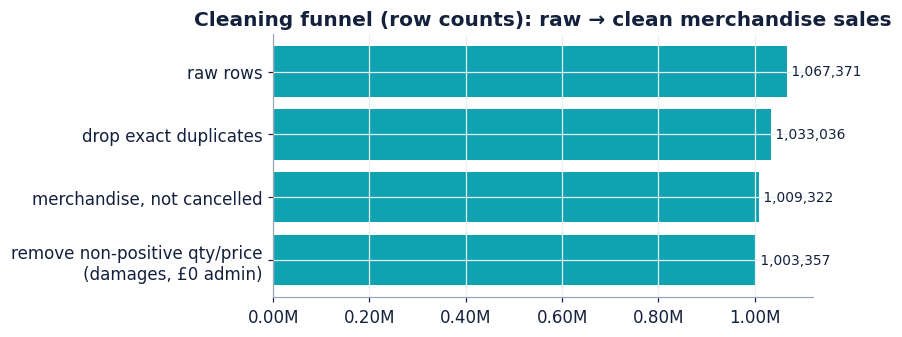

In [12]:
# Define the analysis views Notebook 2 will use, and visualise the funnel from raw -> clean sales.
merch   = prepared[(prepared["nature"] == "Merchandise") & (~prepared["is_cancellation"])]
sales   = merch[(merch["Quantity"] > 0) & (merch["Price"] > 0)]                      # clean merchandise sales
returns = prepared[(prepared["nature"] == "Merchandise") & (prepared["is_cancellation"])]  # product returns

steps = [("raw rows", len(raw)),
         ("drop exact duplicates", len(prepared)),
         ("merchandise, not cancelled", len(merch)),
         ("remove non-positive qty/price\n(damages, £0 admin)", len(sales))]
funnel = pd.DataFrame(steps, columns=["step", "rows"])
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(funnel["step"][::-1], funnel["rows"][::-1], color=TEAL)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
for b, v in zip(bars, funnel["rows"][::-1]):
    ax.text(v, b.get_y()+b.get_height()/2, f" {v:,}", va="center", fontsize=9, color=NAVY)
ax.set_title("Cleaning funnel (row counts): raw → clean merchandise sales")
plt.tight_layout(); plt.show()

In [13]:
# Gross -> returns -> net for merchandise: the headline totals the analysis builds on.
g, r = sales["Revenue"].sum(), returns["Revenue"].sum()
print(f"Gross merchandise sales : £{g:,.0f}  ({len(sales):,} lines)")
print(f"Merchandise returns     : £{r:,.0f}  ({len(returns):,} lines)")
print(f"Net merchandise         : £{g + r:,.0f}")

Gross merchandise sales : £19,643,862  (1,003,357 lines)
Merchandise returns     : £-716,463  (17,915 lines)
Net merchandise         : £18,927,399


## 5. Caveats, assumptions & recommendations

In [14]:
# How much does dropping exact duplicates actually move the numbers? (headline metrics both ways)
def _headline(frame):
    c = frame["Invoice"].astype(str).str.startswith("C")
    m = frame[(frame["nature"] == "Merchandise") & (~c) & (frame["Quantity"] > 0) & (frame["Price"] > 0)]
    uk = m[m["Country"] == "United Kingdom"]["Revenue"].sum() / m["Revenue"].sum() * 100
    return m["Revenue"].sum(), uk, m.groupby("Description")["Revenue"].sum().idxmax()

g_no, uk_no, top_no = _headline(raw)                     # with duplicates
g_de, uk_de, top_de = _headline(raw.drop_duplicates())   # de-duplicated
print(f"gross merch sales — with duplicates £{g_no:,.0f} | de-duplicated £{g_de:,.0f} "
      f"(Δ {(g_no-g_de)/g_no*100:.1f}%)")
print(f"UK revenue share  — {uk_no:.1f}% vs {uk_de:.1f}%   |   top product unchanged: {top_de == top_no}")

gross merch sales — with duplicates £20,110,181 | de-duplicated £19,643,862 (Δ 2.3%)
UK revenue share  — 85.7% vs 85.5%   |   top product unchanged: True


In [15]:
# The duplication is NOT spread evenly across time — check where it concentrates.
def _dec10_merch(f):
    c = f["Invoice"].astype(str).str.startswith("C")
    m = f[(f["nature"] == "Merchandise") & (~c) & (f["Quantity"] > 0) & (f["Price"] > 0)
          & (f["InvoiceDate"].dt.year == 2010) & (f["InvoiceDate"].dt.month == 12)]
    return m["Revenue"].sum()

removed_total = g_no - g_de
removed_dec10 = _dec10_merch(raw) - _dec10_merch(raw.drop_duplicates())
print(f"of the £{removed_total:,.0f} removed by de-duplication, "
      f"£{removed_dec10:,.0f} ({removed_dec10/removed_total*100:.0f}%) is in December 2010 alone.")

of the £466,319 removed by de-duplication, £411,520 (88%) is in December 2010 alone.


**Assumptions & caveats**

- **Exact duplicates are ambiguous.** With no line-level ID and minute-resolution timestamps, an "exact duplicate" could be a genuine repeated line entry rather than an error. Removing them is a *conservative default* worth about 2.3% of revenue — but the duplication is **about 89% concentrated in December 2010** (some lines copied up to 10×), which looks like a one-off technical glitch and, notably, flips whether December's daily sales rate sits above or below November's. Headline conclusions hold either way; the December seasonality read does not.
- **About 23% of rows have no Customer ID** — kept for revenue / product / time analysis, but **excluded from customer-level analysis** (we do not invent identities).
- **December is truncated every year** — data stops around 23 December (2011 ends 9 December), so there is no reliable late-December read.
- **Currency is assumed GBP** (no field in the data); **product categories** (Notebook 2) are a text heuristic.

**Recommendations to improve the data**

1. Add a **line-level identifier** so true duplicates can be told apart from legitimate repeated entries.
2. Provide a **source-system data dictionary** — confirm how postage, fees, adjustments and the `A` / `C` invoice prefixes are booked.
3. Capture a **channel / customer flag** for the unattributed rows (wholesale vs. direct / marketplace).
4. Record **currency** and, ideally, **cost data** (shipping, COGS) to enable margin analysis.

## 6. Save the prepared dataset

De-duplicated, typed, and enriched with `Revenue`, `nature`, and `is_cancellation`. Notebook 2 loads this and derives its analysis views.

In [16]:
# Persist the prepared dataset for Notebook 2.
OUT = DATA_DIR / "online_retail_prepared.parquet"
cols = ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID",
        "Country", "InvoiceDate", "Revenue", "nature", "is_cancellation"]
prepared[cols].to_parquet(OUT, index=False)
print(f"Saved {len(prepared):,} prepared rows -> {OUT}\n")
print(prepared[cols].dtypes.to_string())

Saved 1,033,036 prepared rows -> ../data/online_retail_prepared.parquet

Invoice                    object
StockCode                  object
Description                object
Quantity                    int64
Price                     float64
Customer ID                 Int64
Country                    object
InvoiceDate        datetime64[ns]
Revenue                   float64
nature                     object
is_cancellation              bool


### Sample of the prepared dataset

A quick look at what actually gets handed to Notebook 2.

In [17]:
# A random sample of rows...
prepared[cols].sample(8, random_state=0)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate,Revenue,nature,is_cancellation
312520,519819,22755,SMALL PURPLE BABUSHKA NOTEBOOK,1,0.85,18106,United Kingdom,2010-08-20 13:59:00,0.85,Merchandise,False
717410,553389,20733,GOLD MINI TAPE MEASURE,1,0.83,<NA>,United Kingdom,2011-05-16 16:37:00,0.83,Merchandise,False
614249,543816,22953,BIRTHDAY PARTY CORDON BARRIER TAPE,3,1.25,17841,United Kingdom,2011-02-13 15:26:00,3.75,Merchandise,False
244987,513099,21238,RED SPOTTY CUP,4,1.66,<NA>,United Kingdom,2010-06-21 15:13:00,6.64,Merchandise,False
981248,575647,22735,RIBBON REEL SOCKS AND MITTENS,5,1.65,16440,United Kingdom,2011-11-10 14:16:00,8.25,Merchandise,False
392135,527092,22670,FRENCH WC SIGN BLUE METAL,12,1.25,17101,United Kingdom,2010-10-14 16:09:00,15.00,Merchandise,False
713012,552978,22505,MEMO BOARD COTTAGE DESIGN,24,4.25,12590,Germany,2011-05-12 14:46:00,102.00,Merchandise,False
295089,518140,35400,WOODEN BOX ADVENT CALENDAR,2,8.95,15387,United Kingdom,2010-08-04 16:05:00,17.90,Merchandise,False


In [18]:
# ...and one example line of each 'nature', so the classification is easy to sanity-check.
(prepared.sort_values("is_cancellation")
         .groupby("nature", as_index=False).first()
         [["StockCode", "Description", "Quantity", "Price", "nature", "is_cancellation"]])

,StockCode,Description,Quantity,Price,nature,is_cancellation
0,B,Adjust bad debt,1,11062.06,Adjustment (bad debt),False
1,M,Manual,2,15.00,Fee / adjustment,False
2,gift_0001_10,Dotcomgiftshop Gift Voucher Â£10.00,1,8.33,Gift voucher,False
3,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,Merchandise,False
4,POST,POSTAGE,1,18.00,Shipping charged,False
